# Insurance Cross-Sell Prediction - Data Mining Project
### Correct Pipeline Order (Important!)


## Section 1 - Import Libraries and Load Data

In [1]:
# we import everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random

warnings.filterwarnings('ignore')

# sklearn tools we
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# fuzzy logic library
import skfuzzy as fuzz
from skfuzzy import control as ctrl

print('all libraries imported ok')


all libraries imported ok


In [2]:
# load the dataset
# make sure train.csv
df = pd.read_csv('train.csv')

print('data loaded ok')
print('rows:', df.shape[0])
print('columns:', df.shape[1])
print('column names:', list(df.columns))


data loaded ok
rows: 381109
columns: 12
column names: ['id', 'Gender', 'Age', 'Driving_License', 'Region_Code', 'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium', 'Policy_Sales_Channel', 'Vintage', 'Response']


## Section 2 - Exploratory Data Analysis (EDA)


In [3]:
# look at first
df.head()


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [4]:
# check data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [5]:
# basic statistics like
df.describe()


,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [6]:
# check missing values
print('missing values in each column:')
print(df.isnull().sum())


missing values in each column:
id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64


In [7]:
# check how many
response_counts = df['Response'].value_counts()
print('Response column distribution:')
print(f'  Not Interested (0): {response_counts[0]} customers')
print(f'  Interested     (1): {response_counts[1]} customers')
print(f'  Interest rate: {round(response_counts[1] / len(df) * 100, 2)}%')


Response column distribution:
  Not Interested (0): 334399 customers
  Interested     (1): 46710 customers
  Interest rate: 12.26%


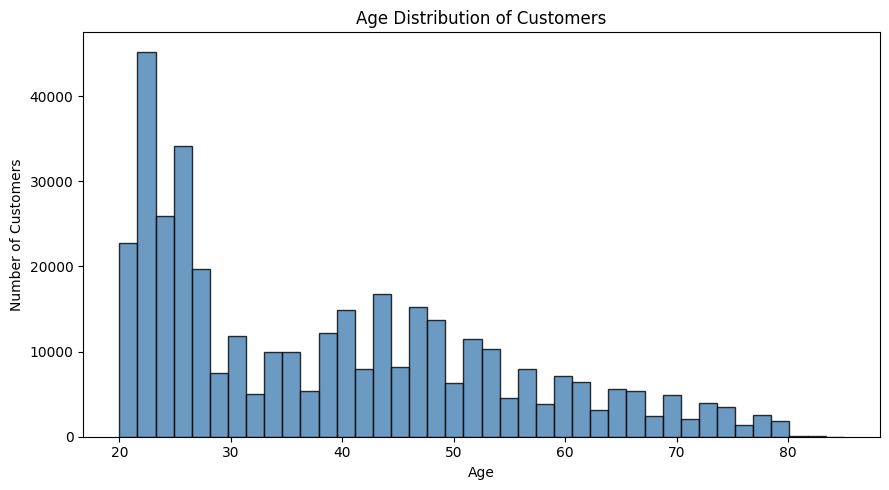

average age: 38.8
min age: 20
max age: 85


In [8]:
# chart 1 -
plt.figure(figsize=(9, 5))
plt.hist(df['Age'], bins=40, color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print('average age:', round(df['Age'].mean(), 1))
print('min age:', df['Age'].min())
print('max age:', df['Age'].max())


### What we see from age


<Figure size 700x500 with 0 Axes>

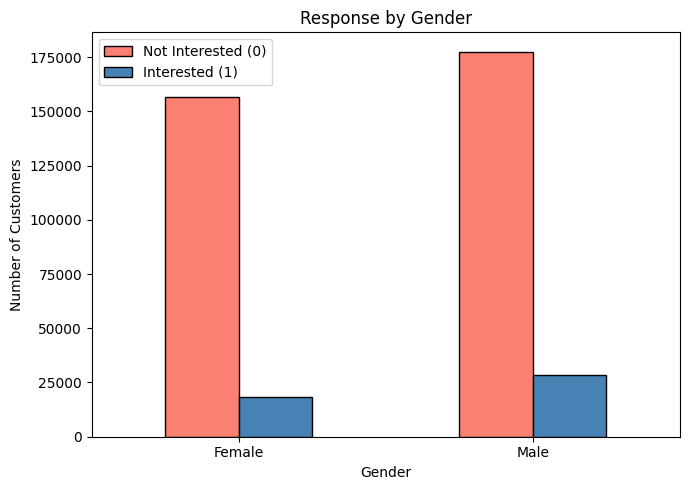

Male: 28525 interested out of 206089 (13.84%)
Female: 18185 interested out of 175020 (10.39%)


In [9]:
# 
 chart 2 - response rate by gender
gender_response = df.groupby(['Gender', 'Response']).size().unstack(fill_value=0)

# 
 figsize is already inside .plot() so no need for plt.figure() here
gender_response.plot(kind='bar', color=['salmon', 'steelblue'], edgecolor='black', figsize=(7, 5))
plt.title('Response by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(['Not Interested (0)', 'Interested (1)'])
plt.tight_layout()
plt.show()

for gender in df['Gender'].unique():
    total = len(df[df['Gender'] == gender])
    interested = len(df[(df['Gender'] == gender) & (df['Response'] == 1)])
    print(f'{gender}: {interested} interested out of {total} ({round(interested/total*100, 2)}%)')


<Figure size 700x500 with 0 Axes>

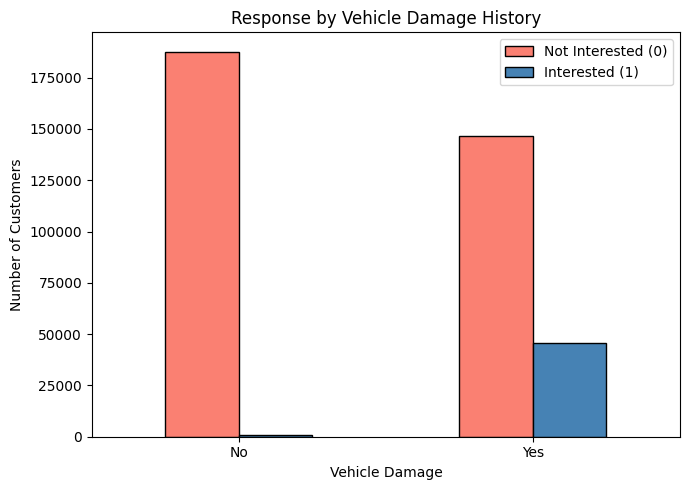

Vehicle_Damage=Yes: 45728 interested out of 192413 (23.77%)
Vehicle_Damage=No: 982 interested out of 188696 (0.52%)


In [10]:
# 
 chart 3 - vehicle damage vs response
damage_response = df.groupby(['Vehicle_Damage', 'Response']).size().unstack(fill_value=0)

# 
 figsize is already inside .plot() so no need for plt.figure() here
damage_response.plot(kind='bar', color=['salmon', 'steelblue'], edgecolor='black', figsize=(7, 5))
plt.title('Response by Vehicle Damage History')
plt.xlabel('Vehicle Damage')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(['Not Interested (0)', 'Interested (1)'])
plt.tight_layout()
plt.show()

for val in df['Vehicle_Damage'].unique():
    total = len(df[df['Vehicle_Damage'] == val])
    interested = len(df[(df['Vehicle_Damage'] == val) & (df['Response'] == 1)])
    print(f'Vehicle_Damage={val}: {interested} interested out of {total} ({round(interested/total*100, 2)}%)')


### Very important finding:


<Figure size 700x500 with 0 Axes>

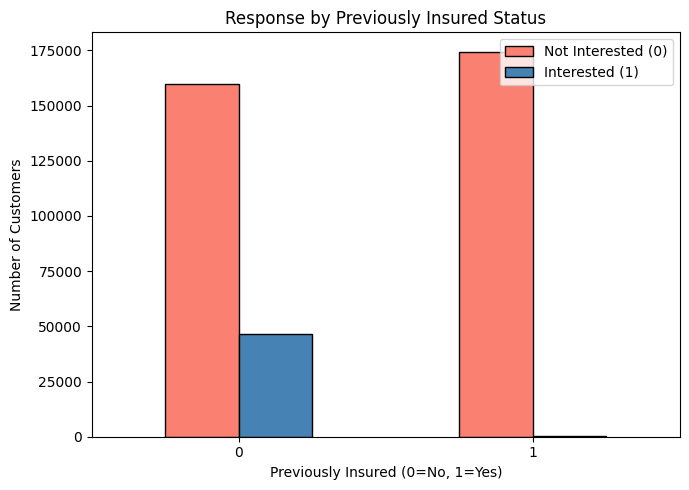

Not Previously Insured: 46552 interested out of 206481 (22.55%)
Already Insured: 158 interested out of 174628 (0.09%)


In [11]:
# 
 chart 4 - previously insured vs response
prev_response = df.groupby(['Previously_Insured', 'Response']).size().unstack(fill_value=0)

# 
 figsize is already inside .plot() so no need for plt.figure() here
prev_response.plot(kind='bar', color=['salmon', 'steelblue'], edgecolor='black', figsize=(7, 5))
plt.title('Response by Previously Insured Status')
plt.xlabel('Previously Insured (0=No, 1=Yes)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(['Not Interested (0)', 'Interested (1)'])
plt.tight_layout()
plt.show()

for val in [0, 1]:
    total = len(df[df['Previously_Insured'] == val])
    interested = len(df[(df['Previously_Insured'] == val) & (df['Response'] == 1)])
    label = 'Already Insured' if val == 1 else 'Not Previously Insured'
    print(f'{label}: {interested} interested out of {total} ({round(interested/total*100, 2)}%)')


### Second most important finding:


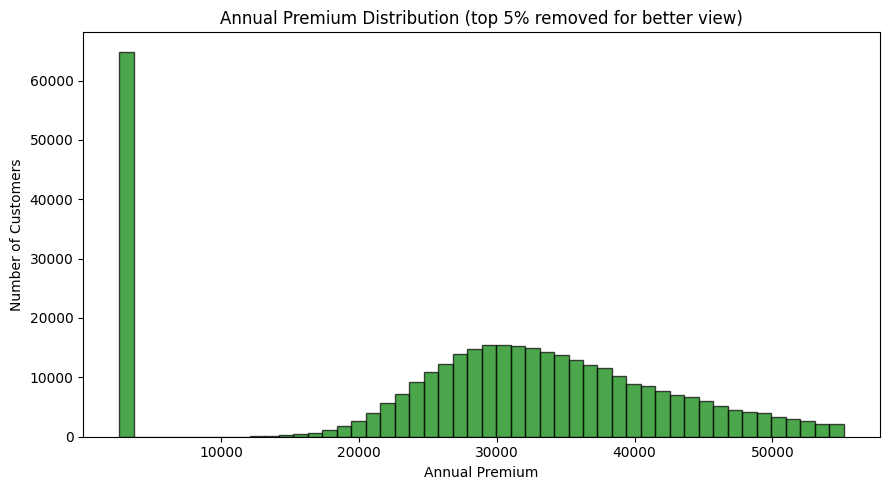

average premium: 30564.39
median premium: 31669.0
max premium: 540165.0


In [12]:
# chart 5 -
premium_data = df[df['Annual_Premium'] < df['Annual_Premium'].quantile(0.95)]

plt.figure(figsize=(9, 5))
plt.hist(premium_data['Annual_Premium'], bins=50, color='green', edgecolor='black', alpha=0.7)
plt.title('Annual Premium Distribution (top 5% removed for better view)')
plt.xlabel('Annual Premium')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print('average premium:', round(df['Annual_Premium'].mean(), 2))
print('median premium:', round(df['Annual_Premium'].median(), 2))
print('max premium:', df['Annual_Premium'].max())


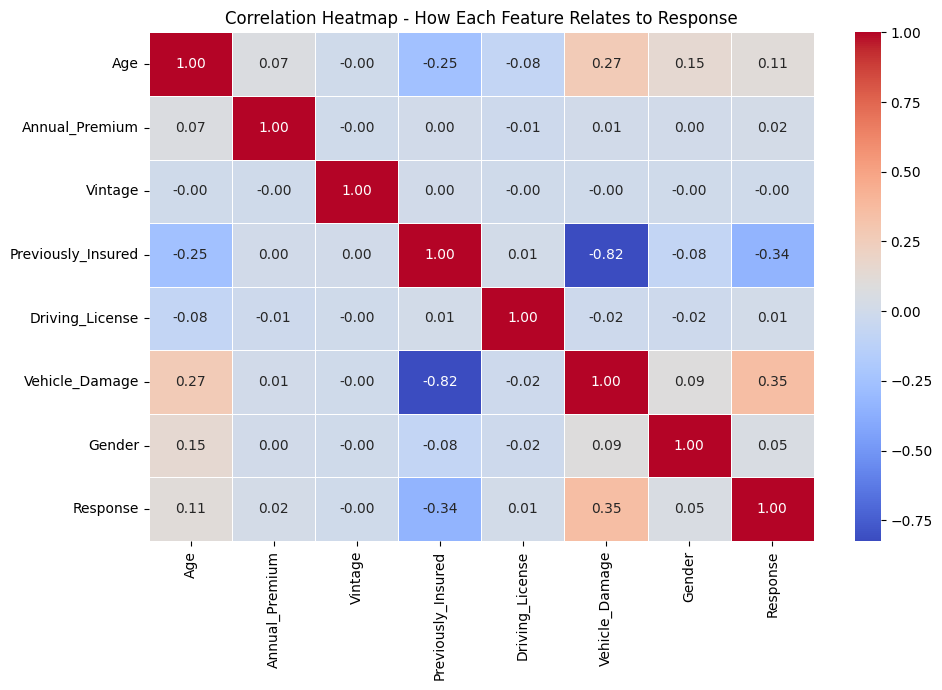

In [13]:
# 
 chart 6 - correlation heatmap
df_temp = df.copy()
df_temp['Gender'] = LabelEncoder().fit_transform(df_temp['Gender'])
df_temp['Vehicle_Damage'] = LabelEncoder().fit_transform(df_temp['Vehicle_Damage'])
df_temp['Vehicle_Age'] = LabelEncoder().fit_transform(df_temp['Vehicle_Age'])

# 
 i added Region_Code and Policy_Sales_Channel here also
# 
 they are used in GA so good to check their correlation with Response
cols_for_heatmap = ['Age', 'Annual_Premium', 'Vintage', 'Previously_Insured',
                    'Driving_License', 'Vehicle_Damage', 'Gender',
                    'Region_Code', 'Policy_Sales_Channel', 'Response']

plt.figure(figsize=(10, 7))
sns.heatmap(df_temp[cols_for_heatmap].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap - How Each Feature Relates to Response')
plt.tight_layout()
plt.show()


### Heatmap result:


## Section 3 - Data Preprocessing


In [14]:
# make a copy
df_clean = df.copy()

# remove id column
df_clean = df_clean.drop('id', axis=1)

print('id column removed')
print('remaining columns:', list(df_clean.columns))


id column removed
remaining columns: ['Gender', 'Age', 'Driving_License', 'Region_Code', 'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium', 'Policy_Sales_Channel', 'Vintage', 'Response']


In [15]:
# step 1 -
print('--- Missing Values BEFORE ---')
print(df_clean.isnull().sum())

# fill missing numbers
for col in ['Age', 'Annual_Premium', 'Vintage']:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
        print(f'filled {col} with median')

# fill missing text
for col in ['Gender', 'Vehicle_Age', 'Vehicle_Damage']:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
        print(f'filled {col} with mode')

print()
print('--- Missing Values AFTER ---')
print(df_clean.isnull().sum())


--- Missing Values BEFORE ---
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

--- Missing Values AFTER ---
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64


In [16]:
# step 2 -
# IQR = Q3
# any value below
# we clip the

print('--- Annual_Premium BEFORE fixing outliers ---')
print(df_clean['Annual_Premium'].describe())

Q1 = df_clean['Annual_Premium'].quantile(0.25)
Q3 = df_clean['Annual_Premium'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers_count = df_clean[(df_clean['Annual_Premium'] < lower_limit) |
                           (df_clean['Annual_Premium'] > upper_limit)].shape[0]

print(f'lower limit: {round(lower_limit, 2)}')
print(f'upper limit: {round(upper_limit, 2)}')
print(f'number of outliers found: {outliers_count}')

df_clean['Annual_Premium'] = df_clean['Annual_Premium'].clip(lower=lower_limit, upper=upper_limit)

print()
print('--- Annual_Premium AFTER fixing outliers ---')
print(df_clean['Annual_Premium'].describe())


--- Annual_Premium BEFORE fixing outliers ---
count    381109.000000
mean      30564.389581
std       17213.155057
min        2630.000000
25%       24405.000000
50%       31669.000000
75%       39400.000000
max      540165.000000
Name: Annual_Premium, dtype: float64
lower limit: 1912.5
upper limit: 61892.5
number of outliers found: 10320

--- Annual_Premium AFTER fixing outliers ---
count    381109.000000
mean      30148.169353
std       15476.398118
min        2630.000000
25%       24405.000000
50%       31669.000000
75%       39400.000000
max       61892.500000
Name: Annual_Premium, dtype: float64


In [17]:
# step 3 -
# machine learning needs

# encode Gender (Male/Female
le_gender = LabelEncoder()
df_clean['Gender'] = le_gender.fit_transform(df_clean['Gender'])
print('Gender encoding:', dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))

# encode Vehicle_Damage (Yes/No
le_damage = LabelEncoder()
df_clean['Vehicle_Damage'] = le_damage.fit_transform(df_clean['Vehicle_Damage'])
print('Vehicle_Damage encoding:', dict(zip(le_damage.classes_, le_damage.transform(le_damage.classes_))))

# encode Vehicle_Age with
# less than 1
vehicle_age_map = {'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 2}
df_clean['Vehicle_Age'] = df_clean['Vehicle_Age'].map(vehicle_age_map)
print('Vehicle_Age encoding:', vehicle_age_map)

print()
print('sample after encoding:')
print(df_clean.head(3))


Gender encoding: {'Female': 0, 'Male': 1}
Vehicle_Damage encoding: {'No': 0, 'Yes': 1}
Vehicle_Age encoding: {'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 2}

sample after encoding:
   Gender  Age  Driving_License  Region_Code  Previously_Insured  Vehicle_Age  \
0       1   44                1         28.0                   0            2   
1       1   76                1          3.0                   0            1   
2       1   47                1         28.0                   0            2   

   Vehicle_Damage  Annual_Premium  Policy_Sales_Channel  Vintage  Response  
0               1         40454.0                  26.0      217         1  
1               0         33536.0                  26.0      183         0  
2               1         38294.0                  26.0       27         1  


In [18]:
# step 4 -
# scaling makes all
# without scaling, Annual_Premium

cols_to_scale = ['Age', 'Annual_Premium', 'Vintage', 'Policy_Sales_Channel', 'Region_Code']

print('--- BEFORE Scaling ---')
print(df_clean[cols_to_scale].describe().loc[['mean', 'std', 'min', 'max']])

scaler = StandardScaler()
df_clean[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

print()
print('--- AFTER Scaling ---')
print(df_clean[cols_to_scale].describe().loc[['mean', 'std', 'min', 'max']])


--- BEFORE Scaling ---
            Age  Annual_Premium     Vintage  Policy_Sales_Channel  Region_Code
mean  38.822584    30148.169353  154.347397            112.034295    26.388807
std   15.511611    15476.398118   83.671304             54.203995    13.229888
min   20.000000     2630.000000   10.000000              1.000000     0.000000
max   85.000000    61892.500000  299.000000            163.000000    52.000000

--- AFTER Scaling ---
               Age  Annual_Premium       Vintage  Policy_Sales_Channel  \
mean -1.148103e-16    2.237290e-18 -9.612889e-17         -7.644074e-17   
std   1.000001e+00    1.000001e+00  1.000001e+00          1.000001e+00   
min  -1.213453e+00   -1.778076e+00 -1.725174e+00         -2.048455e+00   
max   2.976962e+00    2.051147e+00  1.728822e+00          9.402586e-01   

       Region_Code  
mean  1.230509e-17  
std   1.000001e+00  
min  -1.994638e+00  
max   1.935861e+00  


In [19]:
# prepare X (all
# Response is removed
X = df_clean.drop('Response', axis=1)
feature_names = list(X.columns)

print('all features ready for Genetic Algorithm:')
for f in feature_names:
    print('  -', f)
print()
print('X shape:', X.shape)


all features ready for Genetic Algorithm:
  - Gender
  - Age
  - Driving_License
  - Region_Code
  - Previously_Insured
  - Vehicle_Age
  - Vehicle_Damage
  - Annual_Premium
  - Policy_Sales_Channel
  - Vintage

X shape: (381109, 10)


## Section 4 - Genetic Algorithm for Feature Selection


In [20]:
# GA settings -
POPULATION_SIZE = 20    # how many chromosomes we have at once
NUM_GENERATIONS = 30    # how many times we evolve the population
MUTATION_RATE   = 0.1   # chance that each gene flips (0->1 or 1->0)
NUM_FEATURES    = len(feature_names)  # number of genes in each chromosome

print('GA settings:')
print('  population size :', POPULATION_SIZE)
print('  generations     :', NUM_GENERATIONS)
print('  mutation rate   :', MUTATION_RATE)
print('  number of features:', NUM_FEATURES)
print()
print('features we will select from:')
for i, f in enumerate(feature_names):
    print(f'  [{i}] {f}')


GA settings:
  population size : 20
  generations     : 30
  mutation rate   : 0.1
  number of features: 10

features we will select from:
  [0] Gender
  [1] Age
  [2] Driving_License
  [3] Region_Code
  [4] Previously_Insured
  [5] Vehicle_Age
  [6] Vehicle_Damage
  [7] Annual_Premium
  [8] Policy_Sales_Channel
  [9] Vintage


In [21]:
# we use a
# 2000 rows is
ga_sample_size = 2000
np.random.seed(42)
ga_idx = np.random.choice(len(X), ga_sample_size, replace=False)
X_ga = X.iloc[ga_idx].reset_index(drop=True)

print(f'using {ga_sample_size} rows for GA evaluation')
print('shape:', X_ga.shape)


using 2000 rows for GA evaluation
shape: (2000, 10)


In [22]:
# ---- fitness function
# this runs clustering
# we use KMeans
# we use k=3
# we also add
# and we check
from sklearn.cluster import KMeans

def fitness_function(chromosome):
    # get names of
    selected = [feature_names[i] for i in range(NUM_FEATURES) if chromosome[i] == 1]
    
    # we need at
    # if less than
    if len(selected) < 3:
        return 0.0
    
    try:
        # cluster using only
        km = KMeans(n_clusters=3, random_state=42, n_init=5, max_iter=100)
        labels = km.fit_predict(X_ga[selected])
        
        # silhouette score =
        sil = silhouette_score(X_ga[selected], labels)
        
        # check cluster balance
        # calculate size of
        cluster_sizes = []
        for cid in range(3):
            size_pct = (labels == cid).sum() / len(labels)
            cluster_sizes.append(size_pct)
        
        # the smallest cluster
        min_cluster_pct = min(cluster_sizes)
        if min_cluster_pct < 0.05:
            # bad balance -
            sil = sil * 0.5
        
        # small bonus for
        # this prevents GA
        feature_bonus = len(selected) / NUM_FEATURES * 0.05
        
        return sil + feature_bonus
    except:
        return 0.0


# ---- helper functions

def make_chromosome():
    # create one random
    chrom = [random.randint(0, 1) for _ in range(NUM_FEATURES)]
    if sum(chrom) < 3:
        picks = random.sample(range(NUM_FEATURES), 3)
        for p in picks:
            chrom[p] = 1
    return chrom


def crossover(parent1, parent2):
    # single point crossover
    # take first part
    cut_point = random.randint(1, NUM_FEATURES - 1)
    child = parent1[:cut_point] + parent2[cut_point:]
    return child


def mutate(chromosome):
    # flip each gene
    result = chromosome.copy()
    for i in range(NUM_FEATURES):
        if random.random() < MUTATION_RATE:
            result[i] = 1 - result[i]  # flip: 0->1 or 1->0
    
    # make sure at
    if sum(result) < 3:
        picks = random.sample(range(NUM_FEATURES), 3)
        for p in picks:
            result[p] = 1
    return result


print('GA functions ready')
print('fitness function uses k=3 and checks cluster balance')


GA functions ready
fitness function uses k=3 and checks cluster balance


In [23]:
# ---- run the
random.seed(42)
np.random.seed(42)

# calculate baseline: silhouette
baseline_chromosome = [1] * NUM_FEATURES
baseline_score = fitness_function(baseline_chromosome)
print(f'baseline silhouette (all {NUM_FEATURES} features): {round(baseline_score, 4)}')
print()

# create starting population
population = [make_chromosome() for _ in range(POPULATION_SIZE)]

# track best solution
best_chromosome_ever = None
best_score_ever = -1

# track history for
best_score_history = []
avg_score_history = []

print('running GA generations...')
for gen in range(NUM_GENERATIONS):
    
    # step 1: calculate
    fitness_scores = [fitness_function(c) for c in population]
    
    # step 2: track
    best_this_gen = max(fitness_scores)
    avg_this_gen = np.mean(fitness_scores)
    best_score_history.append(best_this_gen)
    avg_score_history.append(avg_this_gen)
    
    # update overall best
    if best_this_gen > best_score_ever:
        best_score_ever = best_this_gen
        best_idx = fitness_scores.index(best_this_gen)
        best_chromosome_ever = population[best_idx].copy()
    
    # print progress every
    if gen % 5 == 0:
        print(f'  gen {gen:02d}: best={round(best_this_gen, 4)} | avg={round(avg_this_gen, 4)}')
    
    # step 3: selection
    scored_pop = sorted(zip(fitness_scores, population), reverse=True)
    survivors = [c for _, c in scored_pop[:POPULATION_SIZE // 2]]
    
    # step 4: create
    new_population = survivors.copy()
    while len(new_population) < POPULATION_SIZE:
        p1 = random.choice(survivors)
        p2 = random.choice(survivors)
        child = mutate(crossover(p1, p2))
        new_population.append(child)
    
    population = new_population

print()
print(f'GA done!')
print(f'best silhouette found: {round(best_score_ever, 4)}')
print(f'baseline silhouette:   {round(baseline_score, 4)}')
improvement = round((best_score_ever - baseline_score) / abs(baseline_score) * 100, 2)
print(f'improvement: {improvement}%')


baseline silhouette (all 10 features): 0.2296

running GA generations...
  gen 00: best=0.4513 | avg=0.3342
  gen 05: best=0.9664 | avg=0.5074
  gen 10: best=0.9664 | avg=0.6968
  gen 15: best=0.9664 | avg=0.8111
  gen 20: best=0.9664 | avg=0.7922
  gen 25: best=0.9664 | avg=0.8201

GA done!
best silhouette found: 0.9664
baseline silhouette:   0.2296
improvement: 320.84%


In [24]:
# show which features
best_features = [feature_names[i] for i in range(NUM_FEATURES) if best_chromosome_ever[i] == 1]
removed_features = [feature_names[i] for i in range(NUM_FEATURES) if best_chromosome_ever[i] == 0]

print('Features SELECTED by Genetic Algorithm:')
for f in best_features:
    print(f'  + {f}')

print()
print('Features REMOVED by Genetic Algorithm:')
for f in removed_features:
    print(f'  - {f}')

print()
print(f'we went from {NUM_FEATURES} features down to {len(best_features)} features')


Features SELECTED by Genetic Algorithm:
  + Driving_License
  + Previously_Insured
  + Vehicle_Damage

Features REMOVED by Genetic Algorithm:
  - Gender
  - Age
  - Region_Code
  - Vehicle_Age
  - Annual_Premium
  - Policy_Sales_Channel
  - Vintage

we went from 10 features down to 3 features


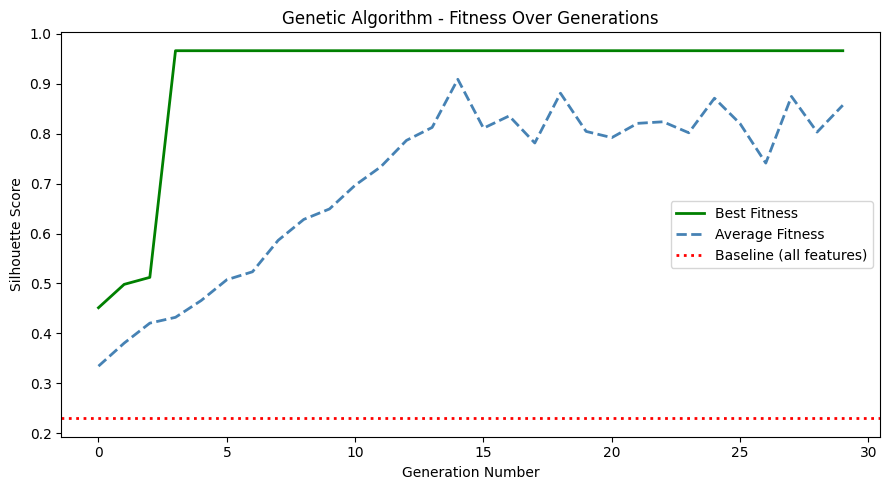

In [25]:
# plot how fitness
plt.figure(figsize=(9, 5))
plt.plot(best_score_history, label='Best Fitness', color='green', linewidth=2)
plt.plot(avg_score_history, label='Average Fitness', color='steelblue', linewidth=2, linestyle='--')
plt.axhline(y=baseline_score, color='red', linestyle=':', linewidth=2, label='Baseline (all features)')
plt.title('Genetic Algorithm - Fitness Over Generations')
plt.xlabel('Generation Number')
plt.ylabel('Silhouette Score')
plt.legend()
plt.tight_layout()
plt.show()


In [26]:
# prepare X_selected -
# this is what
X_selected = X[best_features].copy()

print('X_selected shape:', X_selected.shape)
print('features used for clustering:', best_features)


X_selected shape: (381109, 3)
features used for clustering: ['Driving_License', 'Previously_Insured', 'Vehicle_Damage']


## Section 5 - K-Medoid Clustering


In [27]:
# ---- Simple K-Medoid

class SimpleKMedoids:
    
    def __init__(self, n_clusters=3, max_iter=50, random_state=42):
        # how many clusters
        self.n_clusters = n_clusters
        # maximum number of
        self.max_iter = max_iter
        # random seed for
        self.random_state = random_state
        
        # these will be
        self.medoid_indices_ = None  # index of medoid point for each cluster
        self.labels_ = None          # which cluster each point belongs to
        self.inertia_ = None         # total distance from points to their medoid
    
    
    def fit(self, X):
        # X must be
        np.random.seed(self.random_state)
        X = np.array(X)
        n_samples = X.shape[0]
        
        # step 1: pick
        medoid_indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        
        for iteration in range(self.max_iter):
            
            # step 2: assign
            labels = self._assign_labels(X, medoid_indices)
            
            # step 3: update
            new_medoid_indices = medoid_indices.copy()
            for cluster_id in range(self.n_clusters):
                # get all points
                points_in_cluster = np.where(labels == cluster_id)[0]
                
                if len(points_in_cluster) == 0:
                    # empty cluster -
                    continue
                
                # get the actual
                cluster_data = X[points_in_cluster]
                
                # calculate distance from
                dist_matrix = pairwise_distances(cluster_data, metric='euclidean')
                
                # total distance for
                total_distances = dist_matrix.sum(axis=1)
                
                # the new medoid
                best_local_index = np.argmin(total_distances)
                new_medoid_indices[cluster_id] = points_in_cluster[best_local_index]
            
            # if medoids did
            if np.array_equal(sorted(new_medoid_indices), sorted(medoid_indices)):
                break
            
            medoid_indices = new_medoid_indices
        
        # save results
        self.medoid_indices_ = medoid_indices
        self.labels_ = self._assign_labels(X, medoid_indices)
        self.medoid_points_ = X[medoid_indices]  # save actual medoid coordinates
        
        # calculate inertia =
        total_dist = 0
        for i in range(n_samples):
            cluster_id = self.labels_[i]
            medoid = X[medoid_indices[cluster_id]]
            total_dist += np.linalg.norm(X[i] - medoid)
        self.inertia_ = total_dist
        
        return self
    
    
    def _assign_labels(self, X, medoid_indices):
        # calculate distance from
        medoids = X[medoid_indices]
        distances = pairwise_distances(X, medoids, metric='euclidean')
        # each point belongs
        return np.argmin(distances, axis=1)
    
    
    def predict(self, X_new):
        # assign new points
        X_new = np.array(X_new)
        distances = pairwise_distances(X_new, self.medoid_points_, metric='euclidean')
        return np.argmin(distances, axis=1)


print('SimpleKMedoids class is ready - written from scratch, no library needed')


SimpleKMedoids class is ready - written from scratch, no library needed


In [28]:
# take a sample
# K-Medoid distance matrix
# 5000 rows is
sample_size = 5000
np.random.seed(42)
sample_idx = np.random.choice(len(X_selected), sample_size, replace=False)

# sample from GA-selected
X_sample_selected = X_selected.iloc[sample_idx].reset_index(drop=True)

print(f'using {sample_size} rows for K-Medoid clustering')
print('features used:', list(X_sample_selected.columns))
print('shape:', X_sample_selected.shape)


using 5000 rows for K-Medoid clustering
features used: ['Driving_License', 'Previously_Insured', 'Vehicle_Damage']
shape: (5000, 3)


In [29]:
# find the best
# we try k

inertia_list = []
silhouette_list = []
k_values = list(range(2, 8))

print('testing different k values...')
print()

for k in k_values:
    model = SimpleKMedoids(n_clusters=k, max_iter=50, random_state=42)
    model.fit(X_sample_selected.values)
    
    inertia_list.append(model.inertia_)
    sil_score = silhouette_score(X_sample_selected, model.labels_)
    silhouette_list.append(sil_score)
    
    print(f'k={k} | inertia={round(model.inertia_, 1)} | silhouette={round(sil_score, 4)}')

print()
best_k = k_values[silhouette_list.index(max(silhouette_list))]
print(f'best k based on silhouette score: {best_k}')
print(f'best silhouette score: {round(max(silhouette_list), 4)}')


testing different k values...

k=2 | inertia=466.0 | silhouette=0.8606
k=3 | inertia=130.0 | silhouette=0.9513
k=4 | inertia=130.0 | silhouette=0.9513
k=5 | inertia=130.0 | silhouette=0.9513
k=6 | inertia=130.0 | silhouette=0.9513
k=7 | inertia=130.0 | silhouette=0.9513

best k based on silhouette score: 3
best silhouette score: 0.9513


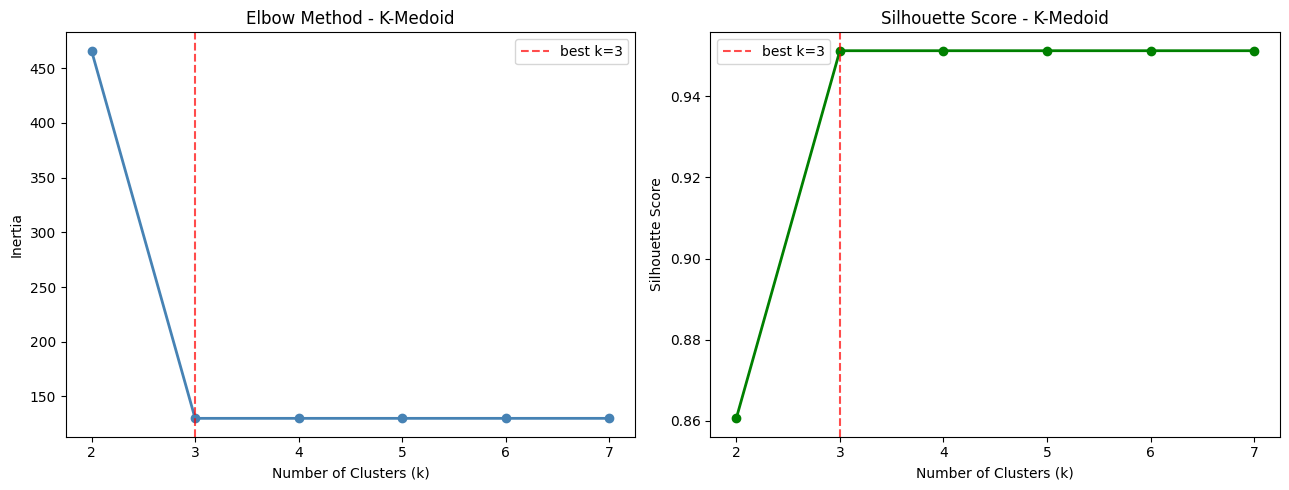

In [30]:
# 
 plot elbow method and silhouette score side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 
 elbow method
axes[0].plot(k_values, inertia_list, marker='o', color='steelblue', linewidth=2)
# 
 note: red line here shows the k chosen by silhouette score (not the elbow itself)
axes[0].axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'silhouette-chosen k={best_k}')
axes[0].set_title('Elbow Method - K-Medoid')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].legend()

# 
 silhouette scores
axes[1].plot(k_values, silhouette_list, marker='o', color='green', linewidth=2)
axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'best k={best_k}')
axes[1].set_title('Silhouette Score - K-Medoid')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.show()


In [31]:
# train the final
print(f'training final K-Medoid with k={best_k} on GA-selected features...')

kmedoids_final = SimpleKMedoids(n_clusters=best_k, max_iter=100, random_state=42)
kmedoids_final.fit(X_sample_selected.values)

# save sample data
df_sample = df.iloc[sample_idx].copy().reset_index(drop=True)
df_sample['KMedoid_Cluster'] = kmedoids_final.labels_

kmed_sil = silhouette_score(X_sample_selected, kmedoids_final.labels_)
print(f'final K-Medoid silhouette score: {round(kmed_sil, 4)}')
print()
print('cluster sizes:')
for cid in range(best_k):
    count = (kmedoids_final.labels_ == cid).sum()
    print(f'  Cluster {cid}: {count} customers')


training final K-Medoid with k=3 on GA-selected features...
final K-Medoid silhouette score: 0.9513

cluster sizes:
  Cluster 0: 2248 customers
  Cluster 1: 2416 customers
  Cluster 2: 336 customers


In [32]:
# analyze each cluster
# we use the

print('=== K-Medoid Cluster Profiles ===')
print('(using GA-selected features on real scaled data, analysis on original values)')
print()

cluster_analysis = df_sample.groupby('KMedoid_Cluster').agg(
    count=('Response', 'count'),
    avg_age=('Age', 'mean'),
    avg_premium=('Annual_Premium', 'mean'),
    pct_vehicle_damage=('Vehicle_Damage', lambda x: (x == 'Yes').mean()),
    pct_previously_insured=('Previously_Insured', 'mean'),
    response_rate=('Response', 'mean')
).round(3)

print(cluster_analysis)
print()

# give each cluster
cluster_labels_dict = {}
print('Cluster Business Labels:')
for cid in range(best_k):
    rr = cluster_analysis.loc[cid, 'response_rate']
    if rr >= 0.35:
        label = 'HOT LEADS - very interested, call immediately'
    elif rr >= 0.12:
        label = 'WARM LEADS - somewhat interested, send campaign'
    else:
        label = 'COLD LEADS - not interested, skip'
    cluster_labels_dict[cid] = label
    print(f'  Cluster {cid} (response={round(rr,3)}): {label}')


=== K-Medoid Cluster Profiles ===
(using GA-selected features on real scaled data, analysis on original values)

                 count  avg_age  avg_premium  pct_vehicle_damage  \
KMedoid_Cluster                                                    
0                 2248   34.672    30587.972               0.052   
1                 2416   42.660    30880.281               1.000   
2                  336   39.188    28954.851               0.000   

                 pct_previously_insured  response_rate  
KMedoid_Cluster                                         
0                                   1.0          0.001  
1                                   0.0          0.258  
2                                   0.0          0.042  

Cluster Business Labels:
  Cluster 0 (response=0.001): COLD LEADS - not interested, skip
  Cluster 1 (response=0.258): WARM LEADS - somewhat interested, send campaign
  Cluster 2 (response=0.042): COLD LEADS - not interested, skip


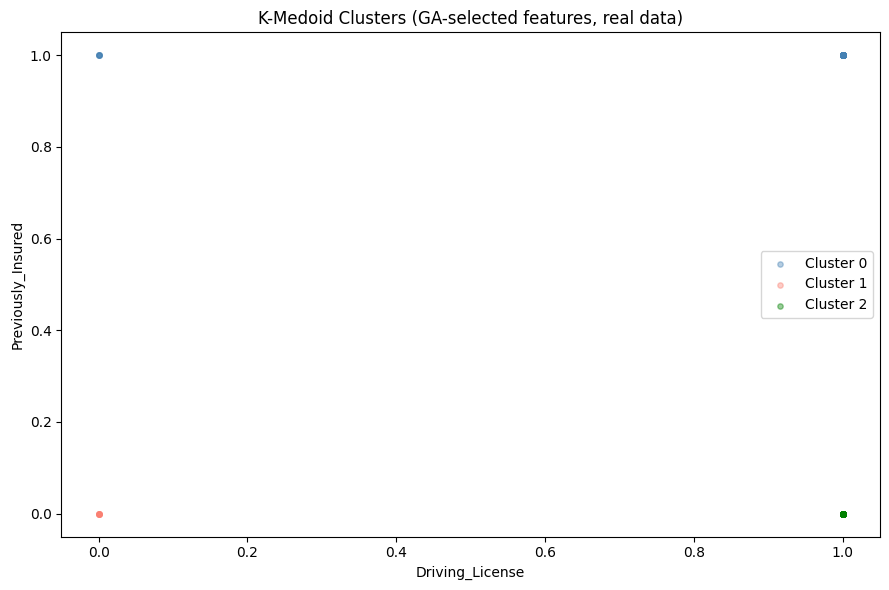

Plot shows clusters in Driving_License vs Previously_Insured space
These are real features with real meaning - not PCA components


In [33]:
# 
 visualize clusters using 2 of the GA-selected features for easy reading
# 
 we pick the 2 most informative features for the scatter plot

# 
 sort clusters by response rate so colors are consistent
cluster_response = df_sample.groupby('KMedoid_Cluster')['Response'].mean()

# 
 pick 2 features that best separate the clusters (highest between-cluster variance)
# 
 this is better than just taking first 2 features from the list
if len(best_features) >= 2:
    # 
 for each feature calculate variance of cluster means
    # 
 high variance = this feature separates clusters well
    between_var = {}
    for f in best_features:
        cluster_means = X_sample_selected.groupby(kmedoids_final.labels_)[f].mean()
        between_var[f] = cluster_means.var()
    # 
 sort features by between-cluster variance (highest first)
    sorted_features = sorted(between_var, key=between_var.get, reverse=True)
    plot_f1 = sorted_features[0]
    plot_f2 = sorted_features[1]
    print(f'picked features with best cluster separation:')
    print(f'  x-axis: {plot_f1} (between-cluster variance = {round(between_var[plot_f1],4)})')
    print(f'  y-axis: {plot_f2} (between-cluster variance = {round(between_var[plot_f2],4)})')
else:
    plot_f1, plot_f2 = feature_names[0], feature_names[1]

cluster_colors = ['steelblue', 'salmon', 'green', 'orange', 'purple']

plt.figure(figsize=(9, 6))
for cid in range(best_k):
    mask = kmedoids_final.labels_ == cid
    f1_vals = X_sample_selected.iloc[mask.tolist()][plot_f1] if plot_f1 in X_sample_selected.columns else X_sample_selected.iloc[mask.tolist(), 0]
    f2_vals = X_sample_selected.iloc[mask.tolist()][plot_f2] if plot_f2 in X_sample_selected.columns else X_sample_selected.iloc[mask.tolist(), 1]
    plt.scatter(f1_vals, f2_vals,
                label=f'Cluster {cid}', alpha=0.4, s=15,
                color=cluster_colors[cid % len(cluster_colors)])

plt.title(f'K-Medoid Clusters - best separating features')
# 
 note: x and y values are scaled (StandardScaler) so they look like -2 to 2
# 
 this is normal - it is because we scaled before clustering
plt.xlabel(f'{plot_f1} (scaled)')
plt.ylabel(f'{plot_f2} (scaled)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Plot shows clusters in {plot_f1} vs {plot_f2} space')
print('note: axes are scaled values (StandardScaler) - this is expected')
print('these are real features with real meaning - not PCA components')


In [34]:
# extend cluster labels
# we use predict()
print('assigning clusters to all rows in full dataset...')

X_full_selected = X_selected.values  # all rows, GA-selected features only
all_cluster_labels = kmedoids_final.predict(X_full_selected)

# save to both
df_clean['KMedoid_Cluster'] = all_cluster_labels
df['KMedoid_Cluster'] = all_cluster_labels

print('done!')
print('cluster distribution in full dataset:')
for cid in range(best_k):
    count = (all_cluster_labels == cid).sum()
    print(f'  Cluster {cid}: {count} customers')


assigning clusters to all rows in full dataset...
done!
cluster distribution in full dataset:
  Cluster 0: 174628 customers
  Cluster 1: 182491 customers
  Cluster 2: 23990 customers


## Section 6 - Hierarchical Clustering


In [35]:
# use same sample
# this is fair

print('testing hierarchical clustering on GA-selected features...')
print('sample shape:', X_sample_selected.shape)
print('features:', list(X_sample_selected.columns))


testing hierarchical clustering on GA-selected features...
sample shape: (5000, 3)
features: ['Driving_License', 'Previously_Insured', 'Vehicle_Damage']


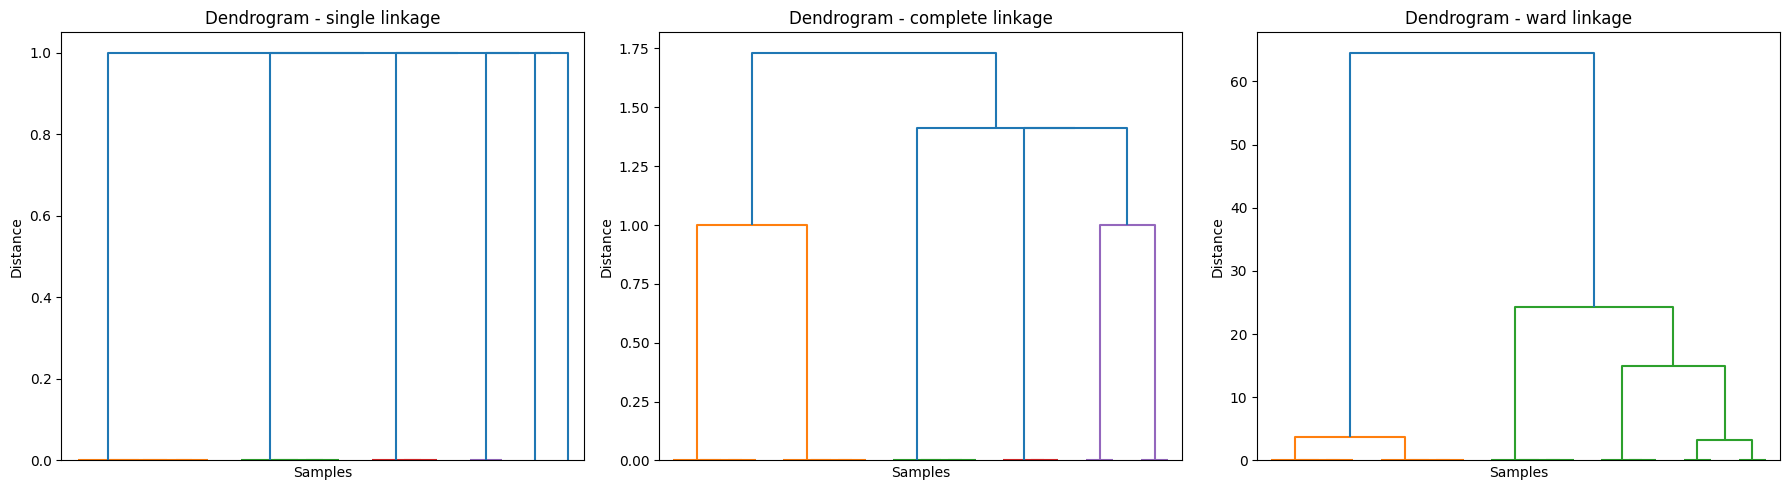

look at the dendrograms - big vertical jumps show natural cluster boundaries


In [36]:
# 
 draw dendrograms for the 3 linkage methods
linkage_methods = ['single', 'complete', 'ward']

plt.figure(figsize=(18, 5))
for i, method in enumerate(linkage_methods):
    plt.subplot(1, 3, i + 1)
    Z = linkage(X_sample_selected, method=method)
    dendrogram(Z, truncate_mode='level', p=4, no_labels=True)
    plt.title(f'Dendrogram - {method} linkage')
    plt.xlabel('Samples')
    plt.ylabel('Distance')

plt.tight_layout()
plt.show()
print('look at the dendrograms - big vertical jumps show natural cluster boundaries')
print('note: y-axis scale is different for each linkage method - this is normal')
print('  single linkage: usually small distances (chaining effect)')
print('  complete linkage: larger distances')
print('  ward linkage: usually best for balanced clusters')


In [37]:
# find best linkage
# but we also
# a cluster is

print('testing all linkage methods and k values...')
print('(we skip results where any cluster has less than 5% of data)')
print()

best_hier_score = -1
best_k_hier = 2
best_linkage_hier = 'ward'

for method in linkage_methods:
    for k in range(2, 7):
        model = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = model.fit_predict(X_sample_selected)
        
        # check cluster balance
        cluster_sizes_pct = []
        for cid in range(k):
            pct = (labels == cid).sum() / len(labels)
            cluster_sizes_pct.append(pct)
        
        min_pct = min(cluster_sizes_pct)
        
        # skip this result
        if min_pct < 0.05:
            print(f'linkage={method} | k={k} | SKIPPED (cluster imbalance, min cluster={round(min_pct*100,1)}%)')
            continue
        
        score = silhouette_score(X_sample_selected, labels)
        print(f'linkage={method} | k={k} | silhouette={round(score, 4)} | min_cluster={round(min_pct*100,1)}%')
        
        if score > best_hier_score:
            best_hier_score = score
            best_k_hier = k
            best_linkage_hier = method

# if no valid
if best_hier_score == -1:
    best_hier_score = 0
    best_k_hier = 2
    best_linkage_hier = 'ward'
    print('no balanced result found - using ward k=2 as fallback')

print()
print(f'best hierarchical: linkage={best_linkage_hier} | k={best_k_hier} | silhouette={round(best_hier_score, 4)}')


testing all linkage methods and k values...
(we skip results where any cluster has less than 5% of data)

linkage=single | k=2 | SKIPPED (cluster imbalance, min cluster=0.1%)
linkage=single | k=3 | SKIPPED (cluster imbalance, min cluster=0.1%)
linkage=single | k=4 | SKIPPED (cluster imbalance, min cluster=0.1%)
linkage=single | k=5 | SKIPPED (cluster imbalance, min cluster=0.1%)
linkage=single | k=6 | SKIPPED (cluster imbalance, min cluster=0.1%)
linkage=complete | k=2 | silhouette=0.8588 | min_cluster=42.6%
linkage=complete | k=3 | silhouette=0.951 | min_cluster=6.7%
linkage=complete | k=4 | SKIPPED (cluster imbalance, min cluster=2.4%)
linkage=complete | k=5 | SKIPPED (cluster imbalance, min cluster=0.1%)
linkage=complete | k=6 | SKIPPED (cluster imbalance, min cluster=0.1%)
linkage=ward | k=2 | silhouette=0.8606 | min_cluster=48.3%
linkage=ward | k=3 | silhouette=0.9513 | min_cluster=6.7%
linkage=ward | k=4 | SKIPPED (cluster imbalance, min cluster=2.4%)
linkage=ward | k=5 | SKIPPED

In [38]:
# train final hierarchical
hier_final = AgglomerativeClustering(n_clusters=best_k_hier, linkage=best_linkage_hier)
hier_labels_sample = hier_final.fit_predict(X_sample_selected)
hier_sil = silhouette_score(X_sample_selected, hier_labels_sample)

df_sample['Hier_Cluster'] = hier_labels_sample

print(f'Hierarchical silhouette score: {round(hier_sil, 4)}')
print('cluster sizes:')
for cid in range(best_k_hier):
    count = (hier_labels_sample == cid).sum()
    print(f'  Cluster {cid}: {count} customers')


Hierarchical silhouette score: 0.9513
cluster sizes:
  Cluster 0: 2248 customers
  Cluster 1: 2416 customers
  Cluster 2: 336 customers


In [39]:
# compare hierarchical cluster
print('=== Hierarchical Cluster Profiles ===')
hier_analysis = df_sample.groupby('Hier_Cluster').agg(
    count=('Response', 'count'),
    avg_age=('Age', 'mean'),
    avg_premium=('Annual_Premium', 'mean'),
    pct_vehicle_damage=('Vehicle_Damage', lambda x: (x == 'Yes').mean()),
    pct_previously_insured=('Previously_Insured', 'mean'),
    response_rate=('Response', 'mean')
).round(3)

print(hier_analysis)
print()

# compare the two
print('=== Comparison: K-Medoid vs Hierarchical ===')
print(f'K-Medoid   silhouette: {round(kmed_sil, 4)}  (k={best_k})')
print(f'Hierarchical silhouette: {round(hier_sil, 4)}  (k={best_k_hier}, linkage={best_linkage_hier})')
print()

if kmed_sil >= hier_sil:
    chosen_method = 'K-Medoid'
    print('K-Medoid wins! We will use K-Medoid results for the fuzzy system.')
    print('Reason: K-Medoid is more robust to outliers because medoids are real data points.')
else:
    chosen_method = 'Hierarchical'
    print('Hierarchical wins! We will use Hierarchical results for the fuzzy system.')
    print('Reason: This linkage method found better cluster boundaries for this dataset.')
    # if hierarchical wins
    print('Note: We still use K-Medoid in the pipeline because it can predict new customers.')


=== Hierarchical Cluster Profiles ===
              count  avg_age  avg_premium  pct_vehicle_damage  \
Hier_Cluster                                                    
0              2248   34.672    30587.972               0.052   
1              2416   42.660    30880.281               1.000   
2               336   39.188    28954.851               0.000   

              pct_previously_insured  response_rate  
Hier_Cluster                                         
0                                1.0          0.001  
1                                0.0          0.258  
2                                0.0          0.042  

=== Comparison: K-Medoid vs Hierarchical ===
K-Medoid   silhouette: 0.9513  (k=3)
Hierarchical silhouette: 0.9513  (k=3, linkage=ward)

K-Medoid wins! We will use K-Medoid results for the fuzzy system.
Reason: K-Medoid is more robust to outliers because medoids are real data points.


## Section 7 - Fuzzy Logic Inference System


In [40]:
# get premium values
# fuzzy system uses
prem_min  = int(df['Annual_Premium'].min())
prem_max  = int(df['Annual_Premium'].max())
prem_q25  = int(df['Annual_Premium'].quantile(0.25))
prem_q50  = int(df['Annual_Premium'].quantile(0.50))
prem_q75  = int(df['Annual_Premium'].quantile(0.75))

print('Annual Premium statistics (original values):')
print(f'  min:    {prem_min}')
print(f'  Q25:    {prem_q25}')
print(f'  median: {prem_q50}')
print(f'  Q75:    {prem_q75}')
print(f'  max:    {prem_max}')


Annual Premium statistics (original values):
  min:    2630
  Q25:    24405
  median: 31669
  Q75:    39400
  max:    540165


In [41]:
# define fuzzy variables

# get premium statistics
# fuzzy system works
prem_min  = int(df['Annual_Premium'].min())
prem_max  = int(df['Annual_Premium'].max())
prem_q25  = int(df['Annual_Premium'].quantile(0.25))
prem_q50  = int(df['Annual_Premium'].quantile(0.50))
prem_q75  = int(df['Annual_Premium'].quantile(0.75))

print('Annual Premium statistics (original values):')
print(f'  min:    {prem_min}')
print(f'  Q25:    {prem_q25}')
print(f'  median: {prem_q50}')
print(f'  Q75:    {prem_q75}')
print(f'  max:    {prem_max}')
print()

# input 1: Age
age_var = ctrl.Antecedent(np.arange(18, 86, 1), 'age')

# input 2: Annual
premium_var = ctrl.Antecedent(np.arange(prem_min, prem_max + 1, 500), 'premium')

# input 3: Previously
prev_var = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'previously_insured')

# input 4: Vehicle
# this is the
damage_var = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'vehicle_damage')

# output: Interest Score
score_var = ctrl.Consequent(np.arange(0, 101, 1), 'interest_score')

print('fuzzy variables created:')
print('  inputs  : age, premium, previously_insured, vehicle_damage')
print('  output  : interest_score (0-100)')


Annual Premium statistics (original values):
  min:    2630
  Q25:    24405
  median: 31669
  Q75:    39400
  max:    540165

fuzzy variables created:
  inputs  : age, premium, previously_insured, vehicle_damage
  output  : interest_score (0-100)


In [42]:
# define membership functions

# -- Age --
# young: 18 to
# middle: 30 to
# senior: 52 to
age_var['young']  = fuzz.trimf(age_var.universe, [18, 18, 38])
age_var['middle'] = fuzz.trimf(age_var.universe, [30, 45, 58])
age_var['senior'] = fuzz.trimf(age_var.universe, [52, 85, 85])

# -- Annual Premium
# low: below median
# medium: around median
# high: above median
premium_var['low']    = fuzz.trimf(premium_var.universe, [prem_min, prem_min, prem_q50])
premium_var['medium'] = fuzz.trimf(premium_var.universe, [prem_q25, prem_q50, prem_q75])
premium_var['high']   = fuzz.trimf(premium_var.universe, [prem_q50, prem_max, prem_max])

# -- Previously Insured
# not_insured: customer does
# insured: customer already
prev_var['not_insured'] = fuzz.trimf(prev_var.universe, [0, 0, 0.5])
prev_var['insured']     = fuzz.trimf(prev_var.universe, [0.5, 1, 1])

# -- Vehicle Damage
# no_damage: customer never
# had_damage: customer had
# customers with damage
damage_var['no_damage']   = fuzz.trimf(damage_var.universe, [0, 0, 0.5])
damage_var['had_damage']  = fuzz.trimf(damage_var.universe, [0.5, 1, 1])

# -- Interest Score
# very_low : 0-25
# low : 10-45
# medium : 35-65
# high : 55-90
# very_high : 80-100
score_var['very_low']  = fuzz.trimf(score_var.universe, [0,   0,  25])
score_var['low']       = fuzz.trimf(score_var.universe, [10,  25, 45])
score_var['medium']    = fuzz.trimf(score_var.universe, [35,  50, 65])
score_var['high']      = fuzz.trimf(score_var.universe, [55,  75, 90])
score_var['very_high'] = fuzz.trimf(score_var.universe, [80, 100, 100])

print('membership functions defined')
print('  age:              young / middle / senior')
print('  premium:          low / medium / high')
print('  previously_insured: not_insured / insured')
print('  vehicle_damage:   no_damage / had_damage')
print('  interest_score:   very_low / low / medium / high / very_high')


membership functions defined
  age:              young / middle / senior
  premium:          low / medium / high
  previously_insured: not_insured / insured
  vehicle_damage:   no_damage / had_damage
  interest_score:   very_low / low / medium / high / very_high


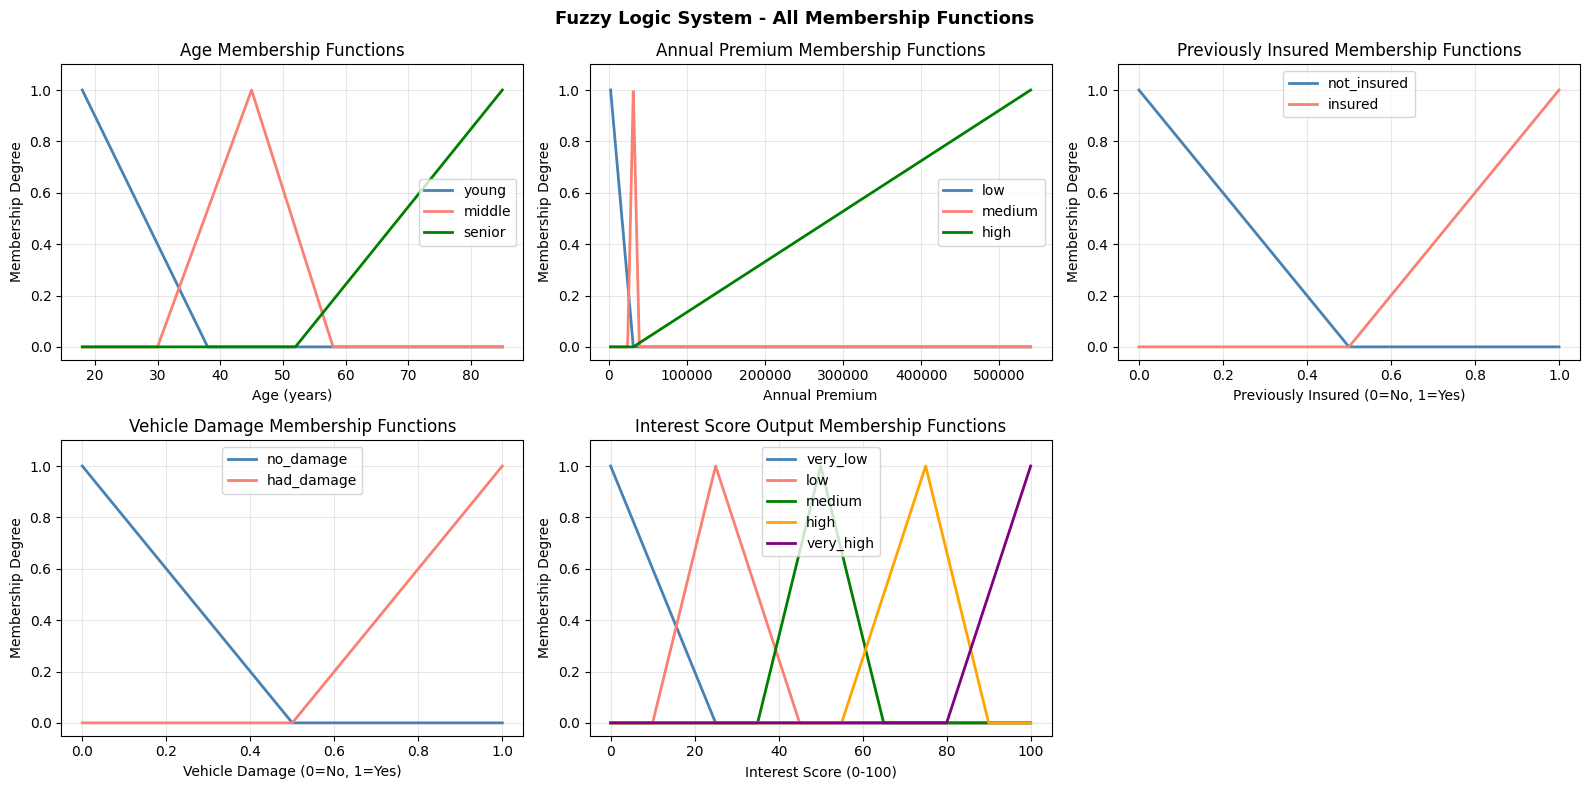

In [43]:
# 
 plot all 4 input membership functions + the output
# 
 i changed from 2x3 grid to 1 row of 5 so no empty 6th panel
colors = ['steelblue', 'salmon', 'green', 'orange', 'purple']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

# 
 age
ax = axes[0]
for i, (name, term) in enumerate(age_var.terms.items()):
    ax.plot(age_var.universe, term.mf, label=name, color=colors[i], linewidth=2)
ax.set_title('Age')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Membership Degree')
ax.legend(fontsize=8)
ax.set_ylim(-0.05, 1.1)
ax.grid(True, alpha=0.3)

# 
 annual premium
ax = axes[1]
for i, (name, term) in enumerate(premium_var.terms.items()):
    ax.plot(premium_var.universe, term.mf, label=name, color=colors[i], linewidth=2)
ax.set_title('Annual Premium')
ax.set_xlabel('Premium Value')
ax.set_ylabel('Membership Degree')
ax.legend(fontsize=8)
ax.set_ylim(-0.05, 1.1)
ax.grid(True, alpha=0.3)

# 
 previously insured
ax = axes[2]
for i, (name, term) in enumerate(prev_var.terms.items()):
    ax.plot(prev_var.universe, term.mf, label=name, color=colors[i], linewidth=2)
ax.set_title('Previously Insured')
ax.set_xlabel('0=No, 1=Yes')
ax.set_ylabel('Membership Degree')
ax.legend(fontsize=8)
ax.set_ylim(-0.05, 1.1)
ax.grid(True, alpha=0.3)

# 
 vehicle damage
ax = axes[3]
for i, (name, term) in enumerate(damage_var.terms.items()):
    ax.plot(damage_var.universe, term.mf, label=name, color=colors[i], linewidth=2)
ax.set_title('Vehicle Damage')
ax.set_xlabel('0=No, 1=Yes')
ax.set_ylabel('Membership Degree')
ax.legend(fontsize=8)
ax.set_ylim(-0.05, 1.1)
ax.grid(True, alpha=0.3)

# 
 output score
ax = axes[4]
for i, (name, term) in enumerate(score_var.terms.items()):
    ax.plot(score_var.universe, term.mf, label=name, color=colors[i], linewidth=2)
ax.set_title('Interest Score (output)')
ax.set_xlabel('Score (0-100)')
ax.set_ylabel('Membership Degree')
ax.legend(fontsize=8)
ax.set_ylim(-0.05, 1.1)
ax.grid(True, alpha=0.3)

# 
 no empty panel now - all 5 subplots are used
plt.suptitle('Fuzzy Logic System - All Membership Functions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Fuzzy Rule Base


In [44]:
# define the IF-THEN
# rules are based
# Vehicle_Damage and Previously_Insured

rules = []

# ---- STRONGEST RULES:

# rule 1: had
rules.append(ctrl.Rule(damage_var['had_damage'] & prev_var['not_insured'], score_var['very_high']))

# rule 2: already
rules.append(ctrl.Rule(prev_var['insured'], score_var['very_low']))

# rule 3: no
rules.append(ctrl.Rule(damage_var['no_damage'] & prev_var['not_insured'], score_var['medium']))

# ---- RULES COMBINING

# rule 4: had
rules.append(ctrl.Rule(damage_var['had_damage'] & age_var['middle'], score_var['very_high']))

# rule 5: had
rules.append(ctrl.Rule(damage_var['had_damage'] & age_var['young'], score_var['high']))

# rule 6: had
rules.append(ctrl.Rule(damage_var['had_damage'] & age_var['senior'], score_var['medium']))

# rule 7: no
rules.append(ctrl.Rule(damage_var['no_damage'] & age_var['senior'], score_var['low']))

# ---- RULES COMBINING

# rule 8: had
rules.append(ctrl.Rule(damage_var['had_damage'] & premium_var['high'], score_var['very_high']))

# rule 9: had
rules.append(ctrl.Rule(damage_var['had_damage'] & premium_var['medium'], score_var['high']))

# rule 10: had
rules.append(ctrl.Rule(damage_var['had_damage'] & premium_var['low'], score_var['medium']))

# rule 11: no
rules.append(ctrl.Rule(damage_var['no_damage'] & premium_var['low'], score_var['low']))

# rule 12: no
rules.append(ctrl.Rule(damage_var['no_damage'] & premium_var['high'], score_var['medium']))

# rule 13: middle
rules.append(ctrl.Rule(age_var['middle'] & prev_var['not_insured'] & premium_var['high'], score_var['very_high']))

print(f'total rules defined: {len(rules)}')
print()
print('most important rules:')
print('  IF had_damage AND not_insured  THEN very_high  (best target)')
print('  IF insured                     THEN very_low   (already has insurance)')
print('  IF had_damage AND middle_age   THEN very_high  (best age + motivation)')


total rules defined: 13

most important rules:
  IF had_damage AND not_insured  THEN very_high  (best target)
  IF insured                     THEN very_low   (already has insurance)
  IF had_damage AND middle_age   THEN very_high  (best age + motivation)


In [45]:
# build the fuzzy
interest_ctrl = ctrl.ControlSystem(rules)
interest_sim = ctrl.ControlSystemSimulation(interest_ctrl)

print('fuzzy control system built and ready')


fuzzy control system built and ready


In [46]:
# test the fuzzy
print('=== Fuzzy System Test on Real Customer Samples ===')
print()
print('Output is a DECISION SCORE (0-100), not a classification accuracy metric')
print()

test_rows = df_sample.sample(5, random_state=7).reset_index(drop=True)

for i, row in test_rows.iterrows():
    try:
        interest_sim.input['age']                = float(row['Age'])
        interest_sim.input['premium']            = float(row['Annual_Premium'])
        interest_sim.input['previously_insured'] = float(row['Previously_Insured'])
        # Vehicle_Damage in original
        dmg_val = 1.0 if row['Vehicle_Damage'] == 'Yes' else 0.0
        interest_sim.input['vehicle_damage']     = dmg_val
        interest_sim.compute()
        score = round(interest_sim.output['interest_score'], 1)
    except Exception as e:
        score = 50.0
    
    if score >= 65:
        priority = 'HIGH PRIORITY - call immediately'
    elif score >= 40:
        priority = 'MEDIUM PRIORITY - send campaign'
    else:
        priority = 'LOW PRIORITY - skip'
    
    dmg_str = 'Yes' if row['Vehicle_Damage'] == 'Yes' else 'No'
    print(f'Customer {i+1}:')
    print(f'  Age={row["Age"]} | Premium={row["Annual_Premium"]} | Prev_Insured={row["Previously_Insured"]} | Vehicle_Damage={dmg_str}')
    print(f'  Actual Response={row["Response"]} | Fuzzy Score={score}/100 | {priority}')
    print()


=== Fuzzy System Test on Real Customer Samples ===

Output is a DECISION SCORE (0-100), not a classification accuracy metric

Customer 1:
  Age=20 | Premium=28783.0 | Prev_Insured=0 | Vehicle_Damage=Yes
  Actual Response=0 | Fuzzy Score=77.9/100 | HIGH PRIORITY - call immediately

Customer 2:
  Age=43 | Premium=38623.0 | Prev_Insured=0 | Vehicle_Damage=Yes
  Actual Response=0 | Fuzzy Score=88.3/100 | HIGH PRIORITY - call immediately

Customer 3:
  Age=42 | Premium=53824.0 | Prev_Insured=0 | Vehicle_Damage=Yes
  Actual Response=0 | Fuzzy Score=93.3/100 | HIGH PRIORITY - call immediately

Customer 4:
  Age=48 | Premium=34215.0 | Prev_Insured=1 | Vehicle_Damage=No
  Actual Response=0 | Fuzzy Score=8.8/100 | LOW PRIORITY - skip

Customer 5:
  Age=31 | Premium=43496.0 | Prev_Insured=1 | Vehicle_Damage=No
  Actual Response=0 | Fuzzy Score=10.5/100 | LOW PRIORITY - skip



## Section 8 - System Implementation


In [47]:
def run_pipeline(customer_dict):
    """
    Takes a new customer as a dictionary.
    Returns cluster number, interest score, and recommendation.
    
    Example input:
    {
        'Gender': 'Male',
        'Age': 30,
        'Driving_License': 1,
        'Region_Code': 28.0,
        'Previously_Insured': 0,
        'Vehicle_Age': '1-2 Year',
        'Vehicle_Damage': 'Yes',
        'Annual_Premium': 35000,
        'Policy_Sales_Channel': 26.0,
        'Vintage': 150
    }
    """
    
    # save original values
    original_age        = customer_dict['Age']
    original_premium    = customer_dict['Annual_Premium']
    original_prev_ins   = customer_dict['Previously_Insured']
    original_damage     = 1.0 if customer_dict['Vehicle_Damage'] == 'Yes' else 0.0
    
    # step 1: make
    record = pd.DataFrame([customer_dict])
    
    # step 2: encode
    record['Gender']         = le_gender.transform(record['Gender'])
    record['Vehicle_Damage'] = le_damage.transform(record['Vehicle_Damage'])
    record['Vehicle_Age']    = record['Vehicle_Age'].map({'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 2})
    
    # step 3: scale
    record[cols_to_scale] = scaler.transform(record[cols_to_scale])
    
    # step 4: keep
    record_for_cluster = record[best_features].values
    
    # step 5: predict
    cluster_label = int(kmedoids_final.predict(record_for_cluster)[0])
    
    # step 6: fuzzy
    try:
        interest_sim.input['age']                = float(original_age)
        interest_sim.input['premium']            = float(original_premium)
        interest_sim.input['previously_insured'] = float(original_prev_ins)
        interest_sim.input['vehicle_damage']     = float(original_damage)
        interest_sim.compute()
        score = round(interest_sim.output['interest_score'], 1)
    except:
        # fallback if fuzzy
        score = 50.0
    
    # step 7: convert
    # threshold lowered to
    if score >= 65:
        recommendation = 'HIGH PRIORITY - Call this customer immediately'
    elif score >= 40:
        recommendation = 'MEDIUM PRIORITY - Send email or SMS campaign'
    else:
        recommendation = 'LOW PRIORITY - Do not spend resources on this customer'
    
    return {
        'cluster'        : cluster_label,
        'cluster_meaning': cluster_labels_dict.get(cluster_label, 'unknown'),
        'interest_score' : score,
        'recommendation' : recommendation
    }


print('pipeline function ready')
print('it uses already-trained models - no re-training happens here')
print()
print('inputs  : Gender, Age, Driving_License, Region_Code, Previously_Insured,')
print('          Vehicle_Age, Vehicle_Damage, Annual_Premium, Policy_Sales_Channel, Vintage')
print('outputs : cluster label + interest score (0-100) + recommendation')


pipeline function ready
it uses already-trained models - no re-training happens here

inputs  : Gender, Age, Driving_License, Region_Code, Previously_Insured,
          Vehicle_Age, Vehicle_Damage, Annual_Premium, Policy_Sales_Channel, Vintage
outputs : cluster label + interest score (0-100) + recommendation


In [48]:
# test the pipeline

print('=== Pipeline Test: 3 Different Customers ===')
print()

# customer 1: young
c1 = {
    'Gender': 'Male', 'Age': 27, 'Driving_License': 1, 'Region_Code': 28.0,
    'Previously_Insured': 0, 'Vehicle_Age': '1-2 Year', 'Vehicle_Damage': 'Yes',
    'Annual_Premium': 35000, 'Policy_Sales_Channel': 26.0, 'Vintage': 130
}
r1 = run_pipeline(c1)
print('Customer 1: Young male, vehicle was damaged, no previous insurance')
print(f'  Cluster: {r1["cluster"]} ({r1["cluster_meaning"]})')
print(f'  Score: {r1["interest_score"]}/100')
print(f'  {r1["recommendation"]}')
print('  Expected: HIGH score because no insurance + vehicle damage')
print()

# customer 2: older
c2 = {
    'Gender': 'Female', 'Age': 63, 'Driving_License': 1, 'Region_Code': 8.0,
    'Previously_Insured': 1, 'Vehicle_Age': '> 2 Years', 'Vehicle_Damage': 'No',
    'Annual_Premium': 24000, 'Policy_Sales_Channel': 152.0, 'Vintage': 210
}
r2 = run_pipeline(c2)
print('Customer 2: Older female, already has insurance, no damage history')
print(f'  Cluster: {r2["cluster"]} ({r2["cluster_meaning"]})')
print(f'  Score: {r2["interest_score"]}/100')
print(f'  {r2["recommendation"]}')
print('  Expected: LOW score because already insured')
print()

# customer 3: middle
c3 = {
    'Gender': 'Male', 'Age': 44, 'Driving_License': 1, 'Region_Code': 15.0,
    'Previously_Insured': 0, 'Vehicle_Age': '1-2 Year', 'Vehicle_Damage': 'Yes',
    'Annual_Premium': 58000, 'Policy_Sales_Channel': 26.0, 'Vintage': 95
}
r3 = run_pipeline(c3)
print('Customer 3: Middle age male, high premium, vehicle damage, no insurance')
print(f'  Cluster: {r3["cluster"]} ({r3["cluster_meaning"]})')
print(f'  Score: {r3["interest_score"]}/100')
print(f'  {r3["recommendation"]}')
print('  Expected: VERY HIGH score - best possible profile')


=== Pipeline Test: 3 Different Customers ===

Customer 1: Young male, vehicle was damaged, no previous insurance
  Cluster: 1 (WARM LEADS - somewhat interested, send campaign)
  Score: 81.2/100
  HIGH PRIORITY - Call this customer immediately
  Expected: HIGH score because no insurance + vehicle damage

Customer 2: Older female, already has insurance, no damage history
  Cluster: 0 (COLD LEADS - not interested, skip)
  Score: 16.5/100
  LOW PRIORITY - Do not spend resources on this customer
  Expected: LOW score because already insured

Customer 3: Middle age male, high premium, vehicle damage, no insurance
  Cluster: 1 (WARM LEADS - somewhat interested, send campaign)
  Score: 93.3/100
  HIGH PRIORITY - Call this customer immediately
  Expected: VERY HIGH score - best possible profile


## Section 9 - Conclusion
### What We Did (Correct Order)
### What We Fixed vs Original Notebook
### Business Findings
